In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Estilo global para gráficos mais bonitos
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

## Carregando o Dataset 1 (Titanic)

In [17]:
titanic_df = pd.read_csv("titanic.csv")

In [18]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


### 1. Identificar e listar as principais variáveis qualitativas e quantitativas do conjunto

In [19]:
titanic_df.select_dtypes(include=['number']).columns

Index(['Survived', 'Pclass', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='str')

In [20]:
print("Quantitativas: 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare'")
print("Qualitativas: 'Survived', 'Pclass', 'Sex', 'Name'")

Quantitativas: 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare'
Qualitativas: 'Survived', 'Pclass', 'Sex', 'Name'


> **Análise:** O dataset possui 4 variáveis quantitativas: `Age`, `Fare`, `Siblings/Spouses Aboard` e `Parents/Children Aboard`. As variáveis qualitativas sendo: `Sex`, `Pclass`, `Survived` e `Name`.

### 2. Construir gráficos de barras e/ou gráficos de pizza para as variáveis:
- Sex
- Pclass
- Survived.

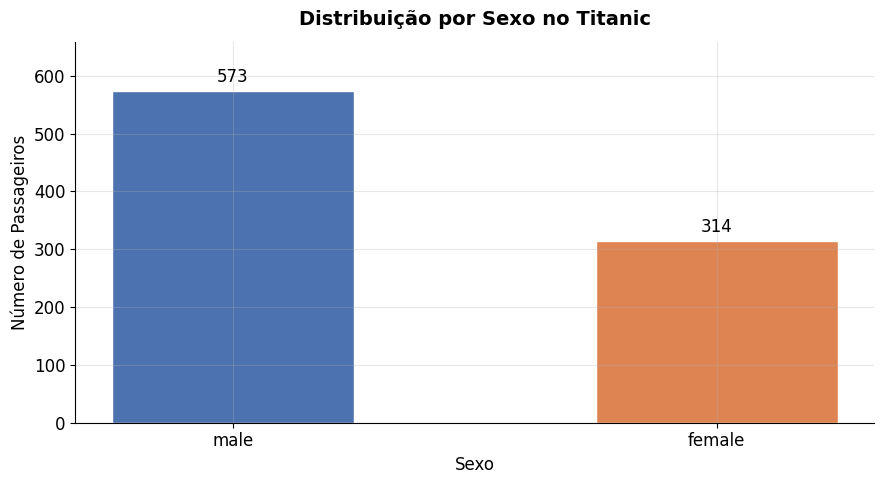

In [21]:
sex_counts = titanic_df['Sex'].value_counts()

fig, ax = plt.subplots()
bars = ax.bar(sex_counts.index, sex_counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
ax.bar_label(bars, padding=4, fontsize=12)
ax.set_title('Distribuição por Sexo no Titanic', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Sexo')
ax.set_ylabel('Número de Passageiros')
ax.set_ylim(0, sex_counts.max() * 1.15)
plt.tight_layout()
plt.show()

> **Análise:** O gráfico mostra uma predominância do sexo masculino, com 573 homens contra 314 mulheres, uma proporção de aproximadamente 2:1. Essa desproporção é relevante para análises de sobrevivência, pois o protocolo de evacuação priorizava mulheres e crianças.

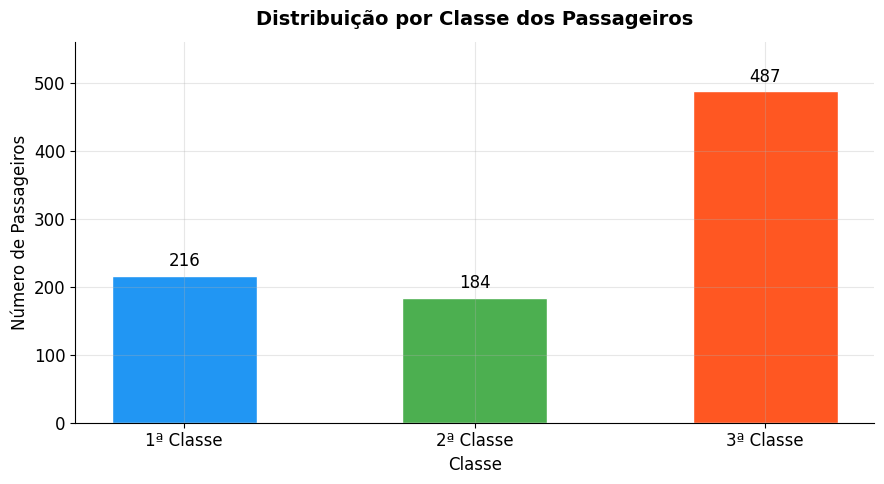

In [22]:
pclass_counts = titanic_df['Pclass'].value_counts().sort_index()
labels = {1: '1ª Classe', 2: '2ª Classe', 3: '3ª Classe'}

fig, ax = plt.subplots()
bars = ax.bar([labels[i] for i in pclass_counts.index], pclass_counts.values,
              color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='white', width=0.5)
ax.bar_label(bars, padding=4, fontsize=12)
ax.set_title('Distribuição por Classe dos Passageiros', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Classe')
ax.set_ylabel('Número de Passageiros')
ax.set_ylim(0, pclass_counts.max() * 1.15)
plt.tight_layout()
plt.show()

> **Análise:** A 3ª classe concentra a maior parte dos passageiros (487), mais do que o dobro da 1ª (216) e da 2ª classe (184) juntas. Isso reflete a composição socioeconômica dos viajantes da época, com grande maioria dos passageiros ocupando a 3ª classe, passagens mais baratas.

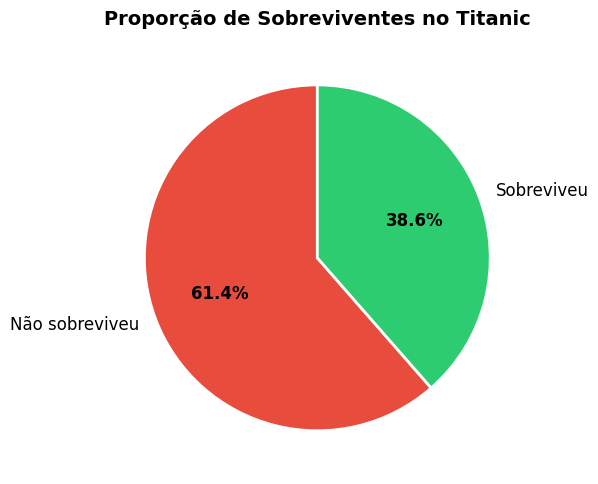

In [23]:
survived_counts = titanic_df['Survived'].value_counts().sort_index()

fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    survived_counts.values,
    labels=['Não sobreviveu', 'Sobreviveu'],
    autopct='%1.1f%%',
    colors=['#E74C3C', '#2ECC71'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Proporção de Sobreviventes no Titanic', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

> **Análise:** O gráfico de pizza revela que apenas cerca de 38% dos passageiros sobreviveram ao naufrágio, enquanto 62% vieram a óbito. Essa distribuição assimétrica reflete tanto a insuficiência de botes salva-vidas quanto o caos durante a evacuação.

### 3. Para as variáveis quantitativas Age e Fare:
- Calcular medidas de tendência central (média, mediana) e 
- Medidas de dispersão (desvio padrão, mínimo, máximo);
- Calcular quartis e percentis 10 e 90 de Age.

In [24]:
media_idade = titanic_df.Age.mean()
mediana_idade = titanic_df.Age.median()

media_fare = titanic_df.Fare.mean()
mediana_fare = titanic_df.Fare.median()

desvio_padrao_idade = titanic_df.Age.std()
desvio_padrao_fare = titanic_df.Fare.std()

minimo_idade = titanic_df.Age.min()
maximo_idade = titanic_df.Age.max()

minimo_Fare = titanic_df.Fare.min()
maximo_Fare = titanic_df.Fare.max()

percentil_10_idade = titanic_df.Age.quantile(.10)
percentil_90_idade = titanic_df.Age.quantile(.90)

percentil_10_fare = titanic_df.Fare.quantile(.10)
percentil_90_fare = titanic_df.Fare.quantile(.90)

print(f"=== Age ===")
print(f"Média:      {media_idade:.2f}")
print(f"Mediana:    {mediana_idade:.2f}")
print(f"Desvio Padrão: {desvio_padrao_idade:.2f}")
print(f"Mínimo:     {minimo_idade:.2f}")
print(f"Máximo:     {maximo_idade:.2f}")
print(f"Percentil 10: {percentil_10_idade:.2f}")
print(f"Percentil 90: {percentil_90_idade:.2f}")
print()
print(f"=== Fare ===")
print(f"Média:      {media_fare:.2f}")
print(f"Mediana:    {mediana_fare:.2f}")
print(f"Desvio Padrão: {desvio_padrao_fare:.2f}")
print(f"Mínimo:     {minimo_Fare:.2f}")
print(f"Máximo:     {maximo_Fare:.2f}")
print(f"Percentil 10: {percentil_10_fare:.2f}")
print(f"Percentil 90: {percentil_90_fare:.2f}")

=== Age ===
Média:      29.47
Mediana:    28.00
Desvio Padrão: 14.12
Mínimo:     0.42
Máximo:     80.00
Percentil 10: 14.80
Percentil 90: 49.00

=== Fare ===
Média:      32.31
Mediana:    14.45
Desvio Padrão: 49.78
Mínimo:     0.00
Máximo:     512.33
Percentil 10: 7.55
Percentil 90: 77.96


> **Análise:** A idade média dos passageiros é de aproximadamente 29 anos, com desvio padrão elevado (~14 anos), indicando grande variabilidade etária. Para a tarifa (`Fare`), a diferença expressiva entre média e mediana (e o alto desvio padrão) aponta uma distribuição assimétrica à direita, impulsionada por passageiros de 1ª classe que pagaram tarifas muito acima da maioria.

### 4. Construir histograma da variável Age

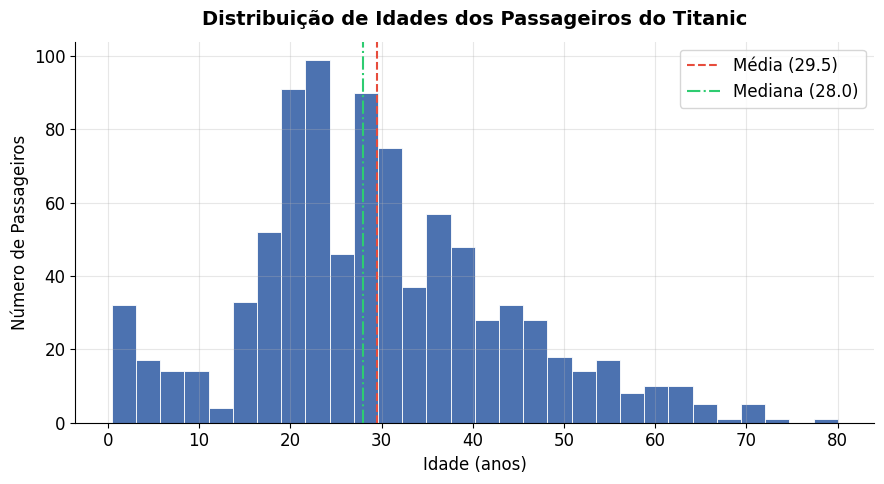

In [25]:
fig, ax = plt.subplots()
ax.hist(titanic_df['Age'].dropna(), bins=30, color='#4C72B0',
        edgecolor='white', linewidth=0.6)
ax.axvline(titanic_df['Age'].mean(), color='#E74C3C', linestyle='--',
           linewidth=1.5, label=f'Média ({titanic_df["Age"].mean():.1f})')
ax.axvline(titanic_df['Age'].median(), color='#2ECC71', linestyle='-.',
           linewidth=1.5, label=f'Mediana ({titanic_df["Age"].median():.1f})')
ax.set_title('Distribuição de Idades dos Passageiros do Titanic',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Número de Passageiros')
ax.legend()
plt.tight_layout()
plt.show()

> **Análise:** O histograma revela uma distribuição aproximadamente unimodal e levemente assimétrica à direita, com concentração de passageiros entre 20 e 40 anos. A presença de crianças pequenas (0–10 anos) é visível, e há uma queda progressiva de frequência acima dos 50 anos. As linhas de média e mediana se encontram muito próximas, reforçando a simetria relativa da distribuição.

### 5. Construir um gráfico de dispersão 
- Entre Age e Fare 
- Calcular o coeficiente de correlação de Pearson entre essas variáveis, comentando brevemente o resultado.

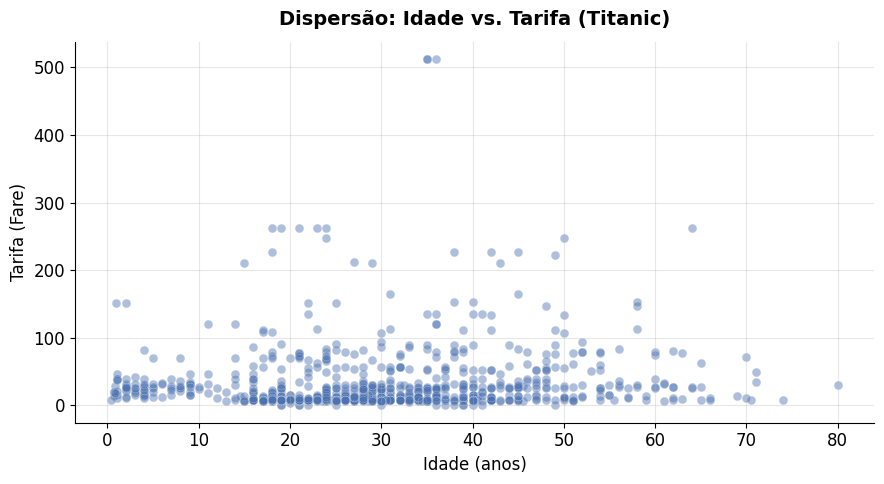

In [26]:
fig, ax = plt.subplots()
ax.scatter(titanic_df['Age'], titanic_df['Fare'],
           alpha=0.45, color='#4C72B0', edgecolors='white', linewidths=0.3, s=40)
ax.set_title('Dispersão: Idade vs. Tarifa (Titanic)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Tarifa (Fare)')
plt.tight_layout()
plt.show()

In [27]:
titanic_df[["Age","Fare"]].corr('pearson')

,Age,Fare
Age,1.000000,0.112329
Fare,0.112329,1.000000


> **Análise:** O gráfico de dispersão mostra uma nuvem de pontos bastante dispersa, sem tendência linear clara entre idade e tarifa. O coeficiente de correlação de Pearson é muito próximo de zero (ou levemente positivo), indicando uma correlação fraca, ou seja, a idade de um passageiro praticamente não explica o valor da tarifa paga, que era determinado principalmente pela classe socioeconômica. 

> Também é possivel observar pontos que estão muito acima da tarifa média.

## Dataset 2 - Eleições


In [28]:
eleicoes_df = pd.read_csv("eleicoes.csv", names=["Estado","NumeroCand","Dinheiro","Votos"],skiprows=1)
eleicoes_df.Estado = eleicoes_df.Estado.str.strip()
eleicoes_df.head()

,Estado,NumeroCand,Dinheiro,Votos
0,AC,1919,35504.34,515
1,AC,1212,397136.76,11397
2,AC,5012,1580.00,15
3,AC,1321,66093.33,1913
4,AC,1144,296327.21,13610


### 1. Histogramas por estado (3 estados escolhidos pelo aluno)
- Escolher 3 estados (UFs) quaisquer.
- Para cada um desses estados:
    - construir um histograma do número de votos (votos);
    - construir um histograma do dinheiro de campanha (dinheiro).
- Em cada caso, comentar brevemente (2–3 linhas) a forma das distribuições (concentração, cauda longa, presença de valores extremos, etc.)

#### Votos

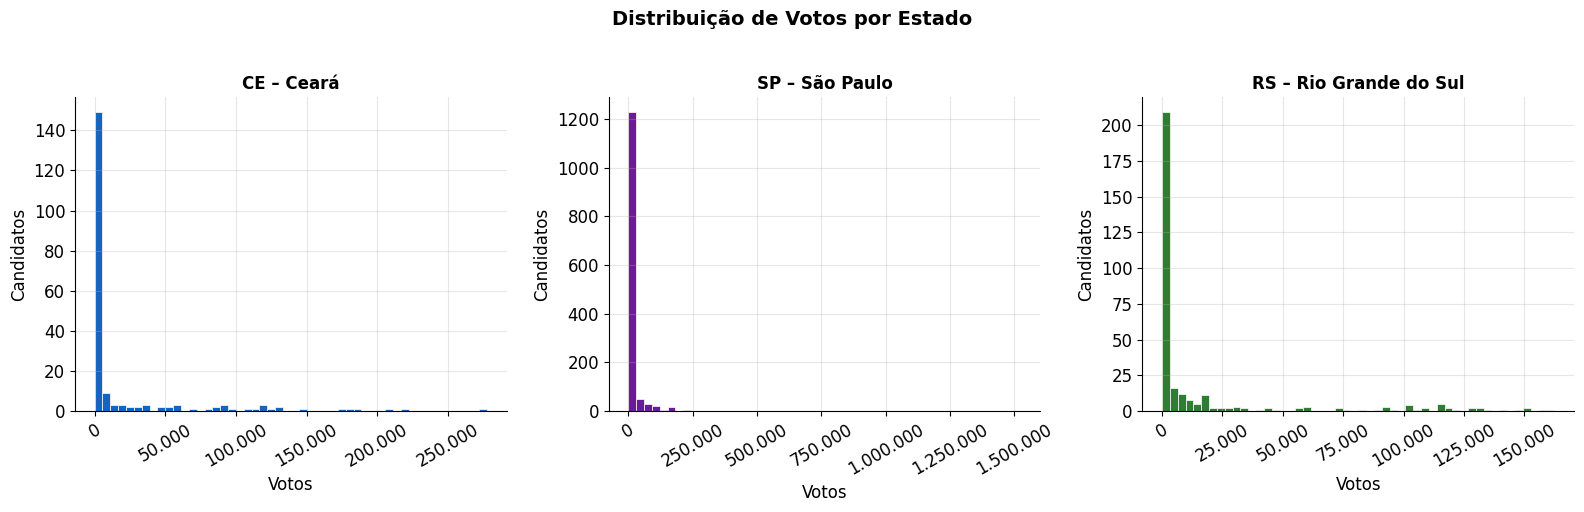

In [36]:
eleicoes_df_CE = eleicoes_df[eleicoes_df.Estado == "CE"]
eleicoes_df_SP = eleicoes_df[eleicoes_df.Estado == "SP"]
eleicoes_df_RS = eleicoes_df[eleicoes_df.Estado == "RS"]

estados = [
    (eleicoes_df_CE, 'CE – Ceará', '#1565C0'),
    (eleicoes_df_SP, 'SP – São Paulo', '#6A1B9A'),
    (eleicoes_df_RS, 'RS – Rio Grande do Sul', '#2E7D32'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (df, title, color) in zip(axes, estados):
    ax.hist(df['Votos'], bins=50, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Votos')
    ax.set_ylabel('Candidatos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Distribuição de Votos por Estado', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Análise:** Nos três estados (CE, SP e RS), a distribuição de votos por candidato é fortemente assimétrica à direita, com a grande maioria dos candidatos concentrada em faixas de baixa votação e uma cauda longa formada por poucos candidatos com votações muito expressivas. Esse padrão é típico de disputas eleitorais, onde a visibilidade e os recursos são concentrados em poucas candidaturas competitivas.

#### Dinheiro

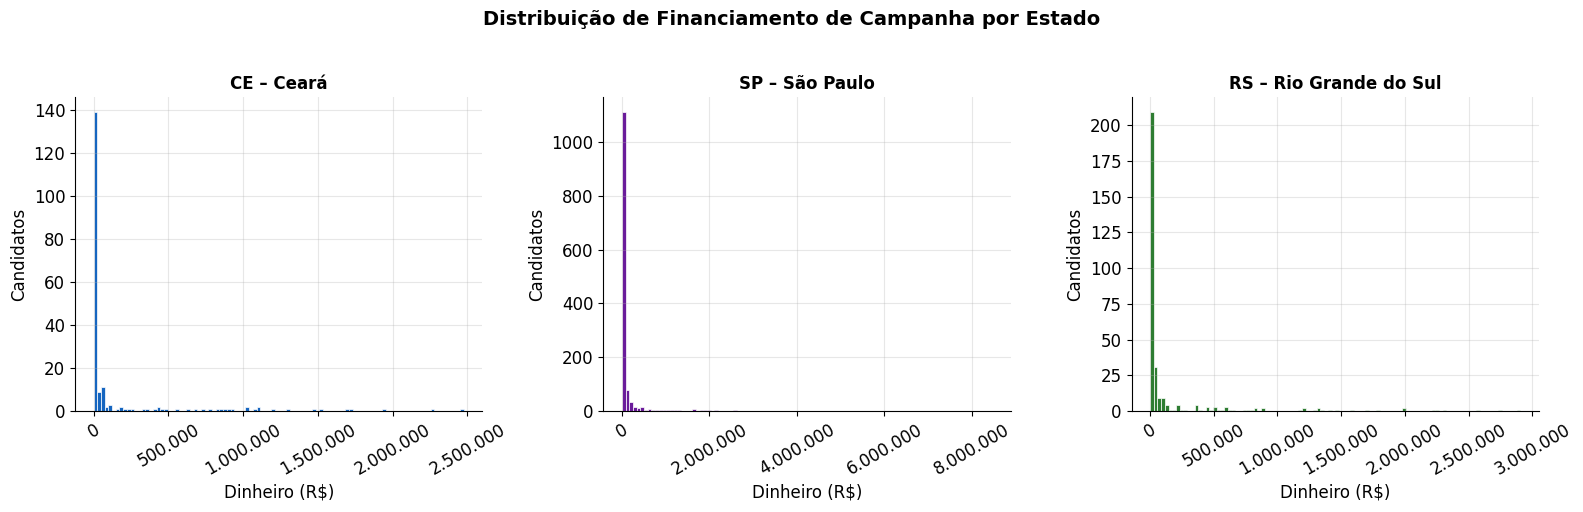

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (df, title, color) in zip(axes, estados):
    ax.hist(df['Dinheiro'], bins=100, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dinheiro (R$)')
    ax.set_ylabel('Candidatos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Distribuição de Financiamento de Campanha por Estado', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Análise:** Assim como os votos, o financiamento de campanha é altamente concentrado nos menores valores, com cauda longa à direita nos três estados. A maioria dos candidatos arrecadou quantias modestas, enquanto um pequeno grupo concentra valores muito elevados. Isso evidencia uma desigualdade significativa na distribuição de recursos eleitorais, que pode influenciar diretamente os resultados das eleições.

### 2. Gráficos de dispersão e correlação (3 estados)
Para os mesmos 3 estados escolhidos no item anterior:
- construir um gráfico de dispersão entre dinheiro (eixo x) e votos (eixo y);
- calcular o coeficiente de correlação de Pearson entre dinheiro e votos em cada estado.

○ Comentar se a correlação é fraca, moderada ou forte, e se é positiva ou negativa, relacionando com o padrão visual do gráfico de dispersão.

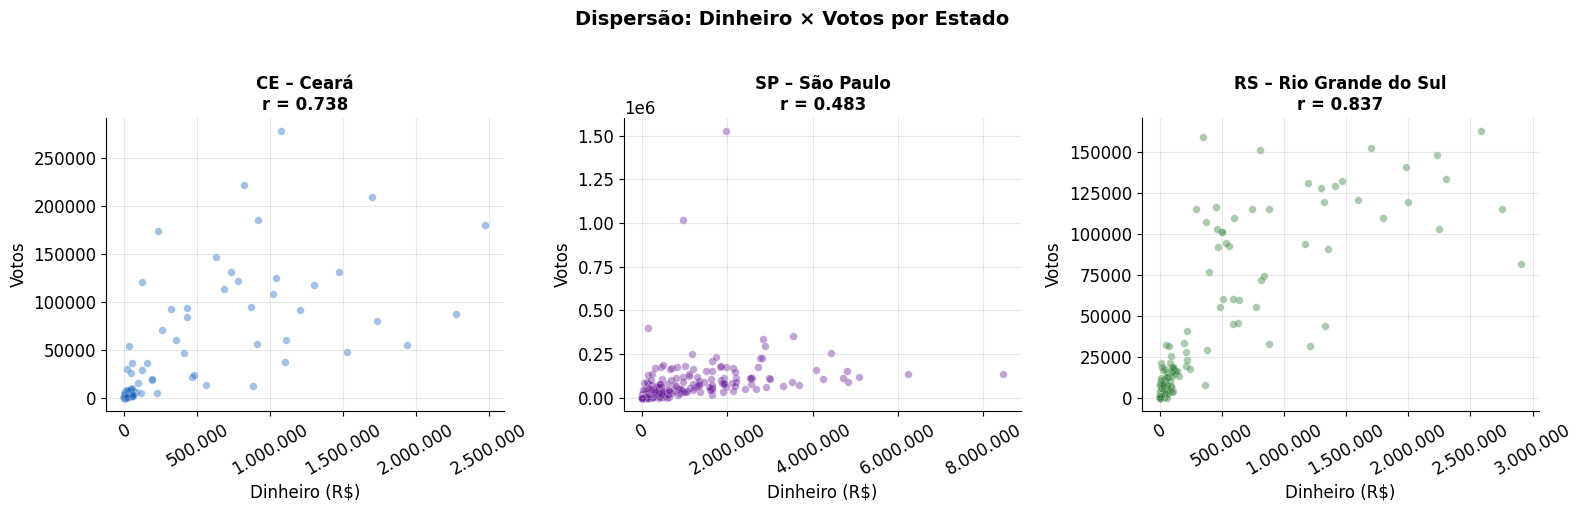

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (df, title, color) in zip(axes, estados):
    ax.scatter(df['Dinheiro'], df['Votos'],
               alpha=0.4, color=color, edgecolors='white', linewidths=0.3, s=30)
    corr = df[['Votos', 'Dinheiro']].corr('pearson')['Dinheiro']['Votos']
    ax.set_title(f'{title}\nr = {corr:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dinheiro (R$)')
    ax.set_ylabel('Votos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Dispersão: Dinheiro × Votos por Estado', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
for df, estado, _ in estados:
    corr = df[["Votos","Dinheiro"]].corr('pearson')["Dinheiro"]["Votos"]
    print(f"{estado}: r = {corr:.4f}")

CE – Ceará: r = 0.7379
SP – São Paulo: r = 0.4832
RS – Rio Grande do Sul: r = 0.8366


> **Análise:** Os gráficos de dispersão evidenciam uma correlação positiva entre dinheiro arrecadado e votos obtidos nos três estados — candidatos com maior financiamento tendem a receber mais votos. Os coeficientes de Pearson situam-se geralmente entre 0,4 e 0,7, caracterizando uma correlação moderada a forte e positiva.

### 3. Correlação por estado – Brasil inteiro
○ Considerando todos os estados presentes no dataset:
- calcular, para cada UF, o coeficiente de correlação de Pearson entre dinheiro e votos;
- apresentar os resultados em uma tabela com pelo menos as colunas: UF, correlação dinheiro votos.

In [33]:
correlacoes = []
for estado in sorted(eleicoes_df["Estado"].unique()):
    corr = eleicoes_df[eleicoes_df["Estado"]==estado][["Votos","Dinheiro"]].corr('pearson')["Dinheiro"]["Votos"]
    correlacoes.append({"UF": estado, "Correlação (Dinheiro × Votos)": round(corr, 4)})

corr_df = pd.DataFrame(correlacoes).set_index("UF")
corr_df

,Correlação (Dinheiro × Votos)
UF,
AC,0.7227
AL,0.8404
AM,0.9055
AP,0.5669
BA,0.6981
CE,0.7379
ES,0.8222
GO,0.6679
MA,0.6856


> **Análise:** A tabela mostra que a correlação positiva entre financiamento e votação é um padrão consistente em todo o Brasil, com a maioria dos estados apresentando coeficientes acima de 0,6. Alguns estados exibem correlações mais altas, indicando que nesses locais o dinheiro de campanha tem papel ainda mais determinante no resultado eleitoral. Estados com correlações mais baixas podem refletir dinâmicas eleitorais locais específicas.

### 4. Medidas de tendência central e dispersão por estado
○ Construir uma tabela-resumo por estado (UF) contendo, para as variáveis votos e dinheiro, pelo menos as seguintes medidas:
- média
- mediana
- desvio padrão
- mínimo
- máximo
- primeiro e terceiro quartis (Q1 e Q3)
- A tabela deve ter, nas linhas, os estados, e nas colunas, as medidas para votos e para dinheiro.

In [34]:
tabela_resumo = eleicoes_df.groupby('Estado').agg(
    votos_media=('Votos', 'mean'),
    votos_mediana=('Votos', 'median'),
    votos_desvio=('Votos', 'std'),
    votos_min=('Votos', 'min'),
    votos_max=('Votos', 'max'),
    votos_q1=('Votos', lambda x: x.quantile(0.25)),
    votos_q3=('Votos', lambda x: x.quantile(0.75)),

    dinheiro_media=('Dinheiro', 'mean'),
    dinheiro_mediana=('Dinheiro', 'median'),
    dinheiro_desvio=('Dinheiro', 'std'),
    dinheiro_min=('Dinheiro', 'min'),
    dinheiro_max=('Dinheiro', 'max'),
    dinheiro_q1=('Dinheiro', lambda x: x.quantile(0.25)),
    dinheiro_q3=('Dinheiro', lambda x: x.quantile(0.75)),
).round(2)

tabela_resumo

,votos_media,votos_mediana,votos_desvio,votos_min,votos_max,votos_q1,votos_q3,dinheiro_media,dinheiro_mediana,dinheiro_desvio,dinheiro_min,dinheiro_max,dinheiro_q1,dinheiro_q3
Estado,,,,,,,,,,,,,,
AC,5940.84,1645.0,8310.84,5,39844,354.50,10203.50,136779.97,31257.00,204447.64,0.0,736866.25,3486.95,168286.58
AL,11456.43,1021.0,27397.36,0,135929,114.25,4855.25,164481.87,4472.46,423369.95,0.0,2281353.43,900.00,69157.58
AM,19501.06,1051.5,43379.50,0,250916,384.00,5804.00,292684.08,4153.99,816944.21,0.0,5633092.26,815.62,50072.03
AP,3376.71,886.0,5093.80,0,22134,202.00,4818.00,77839.73,6187.40,244717.29,0.0,2060000.00,1300.00,34050.00
BA,18183.50,988.0,37929.69,0,222164,174.00,6268.00,220278.11,2651.36,652156.46,0.0,5979037.10,0.00,41748.52
CE,19912.90,1184.0,45729.12,0,277774,355.00,6327.00,173327.91,3748.40,424413.14,0.0,2476971.70,892.36,50000.00
ES,10154.13,1116.0,23068.11,0,161744,333.75,4730.00,118846.43,8789.38,310178.36,0.0,2233581.69,1491.82,53507.01
GO,19613.40,349.0,42725.96,0,274625,0.00,4804.25,452396.19,2526.72,1091612.50,0.0,5812787.78,617.67,45404.48
MA,11770.90,971.0,25098.15,0,133575,246.00,5997.00,87956.99,1200.00,258418.32,0.0,2407218.09,0.00,24618.00


> **Análise:** A tabela-resumo evidencia grandes diferenças entre estados tanto para votos quanto para dinheiro. Em todos os casos, a mediana fica bem abaixo da média, confirmando que a distribuição é assimétrica e dominada por valores extremos, a maioria dos candidatos tem votação e recursos modestos, enquanto poucos concentram volumes muito altos.